In [30]:
from methods_script.OFIT.local_image import rev_image

import cv2
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import patches, cm, colors
from sklearn.cluster import DBSCAN
from ellipse import LsqEllipse
import pickle
from scipy.optimize import curve_fit

def flat(p):
    return p.reshape(-1,p.shape[-1])

# Detect structural parts of tokamak

## Edge detection for ports and center

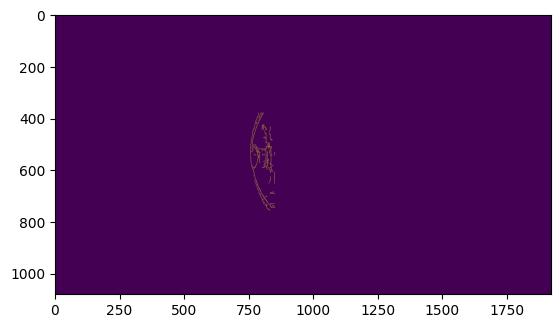

In [31]:
shot_961_200 = cv2.blur(rev_image(961,200), (3,3))
edge_200 = cv2.Canny(shot_961_200,0,30)
edge_200[:,0:750] = 0
edge_200[:,850:] = 0
edge_200[0:380,:] = 0
edge_200[760:,:] = 0
# edge_200[300:450,800:] = 0
plt.imshow(edge_200)

In [32]:
def remove_small_cluster(x:NDArray, y:NDArray, eps: float, min_samples: int, threshold: int) -> tuple[NDArray,NDArray]:
    """
    remove noise cluster using DBSCAN

    :param x: coordinate of edge along horizontal direction
    :param y: coordinate of edge along vertical direction
    :param eps: eps parameter for DBSCAN
    :param min_samples: minimum sample size to be considered as cluster
    :param threshold: threshold size to cutoff small size clusters
    :return: filtered pairwise coordinate (u,v) by clustering
    """
    #stack data
    stack = np.column_stack((x,y))

    # Apply DBSCAN clustering
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(stack)

    # Count the size of each cluster
    unique_labels, counts = np.unique(labels, return_counts=True)

    # Identify clusters smaller than the threshold
    small_clusters = unique_labels[counts < threshold]

    # Remove points belonging to small clusters
    mask = ~np.isin(labels, small_clusters)
    filtered_stack = stack[mask]

    return filtered_stack[:,0], filtered_stack[:,1]


NameError: name 'NDArray' is not defined

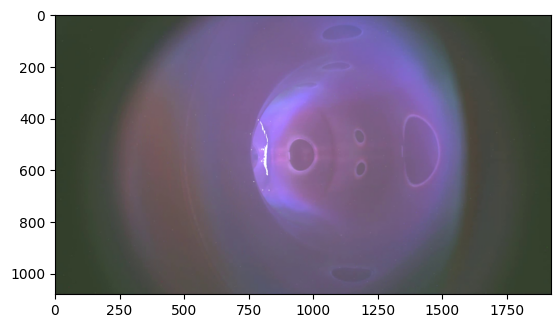

In [33]:
from methods_script.OFIT.detection_projection import kernel_filter

shot_961_198_clor = cv2.blur(rev_image(961,198), (3,3))
shot_961_198 = cv2.cvtColor(shot_961_198_clor, cv2.COLOR_RGB2GRAY)
shot_961_198 = kernel_filter(shot_961_198)
shot_961_198 = cv2.fastNlMeansDenoising(shot_961_198, h=10)


ROI_201 = shot_961_198[405:690,750:840]
ys, xs = np.where(ROI_201 > 50)

y_shifted, x_shifted = ys + 405, xs + 750
shot_961_198_clor[y_shifted,x_shifted] = 255
plt.imshow(shot_961_198_clor)

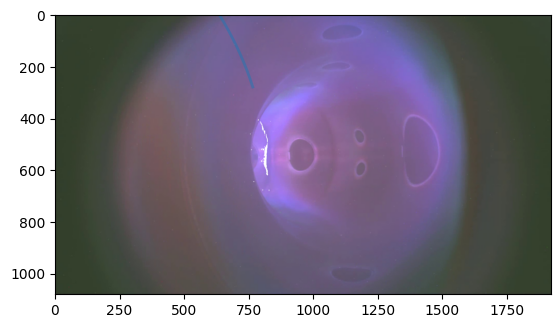

In [34]:
def side_parabola(y,a,b,c):
    return a*y**2 + b*y + c
params_link, cov = curve_fit(side_parabola, y_shifted, x_shifted)

plt.imshow(shot_961_198_clor)
y_link = np.linspace(380,700,1000)
x_link = side_parabola(y_link, *params_link)

plt.plot(side_parabola(ys,*params_link),ys,alpha = 0.5,lw = 2)

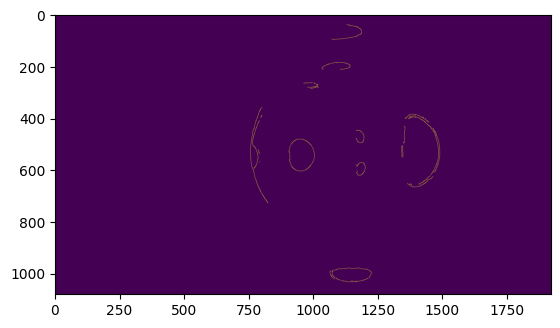

In [35]:
##### use shot 961 frame 187,57, and 200 as reference (previously used frame 167)

#retreive images and blur frame 187
shot_961_57 = cv2.blur(rev_image(961,57), (3,3))
shot_961_187 = cv2.blur(rev_image(961,187), (3,3))
shot_961_200 = cv2.blur(rev_image(961,200), (3,3))

#do edge detection for both image
edge_57 = cv2.Canny(shot_961_57,0,80)
edge_187 = cv2.Canny(shot_961_187,0,40)
edge_200 = cv2.Canny(shot_961_200,0,80)

#manually remove noises
edge_57[400:700,800:900] = 0
edge_57[:,0:500] = 0
edge_57[200:400,840:920] = 0
edge_57[:,1225:1300] = 0
edge_57[:,:650] = 0
edge_57[:,1510:] = 0

#at some parts frame 187 give better detection
y1i,y1f = 850, 1080
x1i,x1f = 1000,1500
ROI1 = edge_187[y1i:y1f,x1i:x1f]
ROI1[0:50,:] = 0

y2i, y2f = 240, 300
x2i, x2f = 960, 1020
ROI2 = edge_187[y2i:y2f,x2i:x2f]

#find tokamak center from frame 200

edge_200[:,0:750] = 0
edge_200[:,900:] = 0
edge_200[300:450,800:] = 0

y3i, y3f = 0, 1020
x3i, x3f = 0, 900
ROI3 = edge_200[y3i:y3f,x3i:x3f]

#combine the two frame
edge_57[y1i:y1f,x1i:x1f] = ROI1
edge_57[y2i:y2f,x2i:x2f] = ROI2
edge_57[y3i:y3f,x3i:x3f] = ROI3

edge_57[730:,0:1000] = 0
edge_57[220:250,1000:1100] = 0
edge_57[:,0:750] = 0
edge_57[0:300,750:900] = 0
edge_57[400:600,790:900] = 0

TT1_structure = edge_57
plt.imshow(TT1_structure)

## separate part of structures into parts

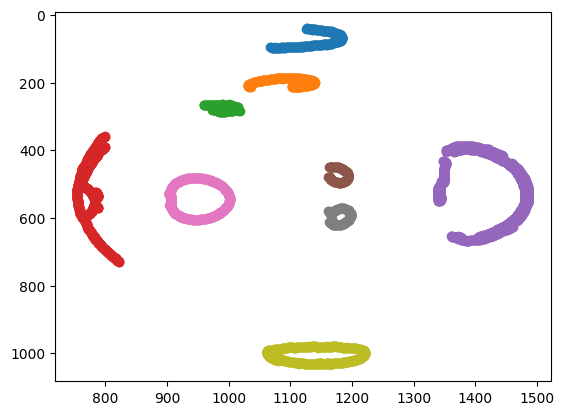

In [36]:
ys, xs = np.where(TT1_structure > 0)

model = DBSCAN(eps = 60,min_samples = 5)
edge_coordinate = np.column_stack((xs,ys))

model.fit(edge_coordinate)
yhat = model.fit_predict(edge_coordinate)

#retrieve unique clusters
clusters = np.unique(yhat)

#plot groups
for cluster in clusters:
	# get row indexes for samples with this cluster
	row_ix = np.where(yhat == cluster)
	# create scatter of these samples
	plt.scatter(edge_coordinate[row_ix, 0], edge_coordinate[row_ix, 1])

plt.gca().invert_yaxis()

## curve fit for TT1 center

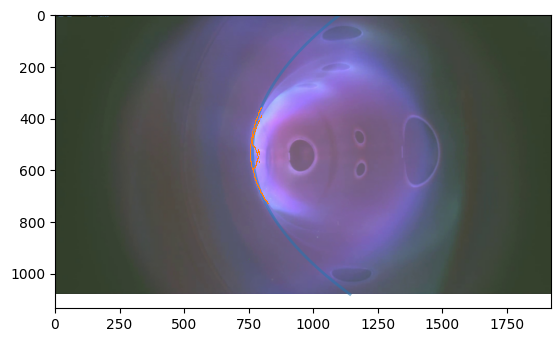

In [37]:
tokamak_center = edge_coordinate[yhat == 3]
tx, ty = tokamak_center[:,0], tokamak_center[:,1]
def side_parabola(y,a,b,c):
    return a*y**2 + b*y + c
center_params, cov = curve_fit(side_parabola, ty, tx)

plt.imshow(shot_961_187)
ys = np.linspace(0,shot_961_187.shape[0],1000)
plt.plot(side_parabola(ys,*center_params),ys,alpha = 0.5,lw = 2)
plt.plot(tx,ty,",")
# plt.gca().invert_yaxis()

## fit ellipse equation to each port

Text(0.5, 1.0, 'detected ports and structure')

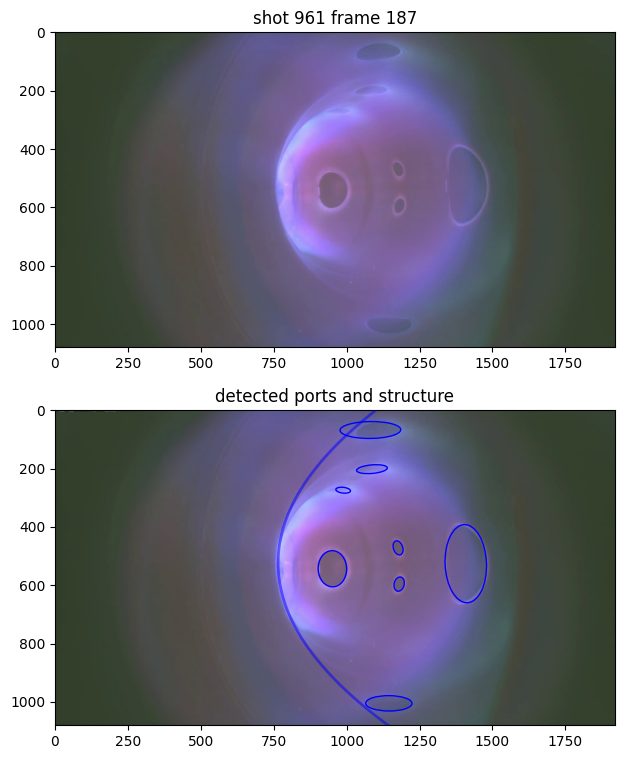

In [38]:
fig, (ax1,ax2) = plt.subplots(2, figsize = (16,9))
for hat in np.unique(yhat):
    if hat != 3:
        hat_points = edge_coordinate[yhat == hat]
        x_val, y_val = hat_points[:,0], hat_points[:,1]

        X = np.array(list(zip(x_val,y_val)))
        reg = LsqEllipse().fit(X)
        center, width, height, phi = reg.as_parameters()
        
        ellipse = patches.Ellipse(
            xy=center, width=2*width, height=2*height, angle=np.rad2deg(phi),
            edgecolor='b', fc='None', lw=1, label='Fit', zorder=2)
        
        ax2.add_patch(ellipse)
ax1.imshow(shot_961_187)
ax2.imshow(shot_961_187)
ax2.plot(side_parabola(ys,*center_params),ys,alpha = 0.5,lw = 2, color = "b")
ax2.set_ylim(0,1080)
plt.gca().invert_yaxis()

ax1.set_title("shot 961 frame 187")
ax2.set_title("detected ports and structure")

# plt.savefig(r"C:\Users\pitit\Documents\01_MUIC_work\ICPY 441 Senior project\meetings\ASPNF_meeting/structure")

        
        
        

# Exclude parts

## port edges

In [39]:
#set of every pixel coordinate where the color pigment is excluded
#result of calculation
ex_set = set(())
port_set = set(())
###

height, width, _ = shot_961_200.shape

ellip_set = set(())
def ellipse(center,width,height,phi):
    width, height = 2*width, 2*height
    t = np.linspace(0,2*np.pi,500)
    x0, y0 = center

    xs = x0 + width/2*np.cos(t)*np.cos(phi) - height/2*np.sin(t)*np.sin(phi)
    ys = y0 + width/2*np.cos(t)*np.sin(phi) + height/2*np.sin(t)*np.cos(phi)

    return xs,ys
    
for hat in np.unique(yhat):
    #find ellipse equation for each port
    if hat != 3:
        hat_points = edge_coordinate[yhat == hat]
        x_val, y_val = hat_points[:,0], hat_points[:,1]

        X = np.array(list(zip(x_val,y_val)))
        reg = LsqEllipse().fit(X)

        xe, ye = ellipse(*reg.as_parameters())
        xe, ye = np.floor(xe).astype(int), np.floor(ye).astype(int)
        xy_ellip = np.column_stack((xe,ye))
        ellip_set.update(tuple(xy) for xy in xy_ellip)

        # ex_set.update(ellip_set)
        # port_set.update(ellip_set)


        #add neighboring pixels to excluding set
        for xy in xy_ellip:
            x, y = xy
                
            # size of motion
            half_side_len = 8 if (hat == 4 or hat == 6) else 8
            # Generate neighbors within the square of half side length
            for dx in range(-half_side_len, half_side_len + 1):
                for dy in range(-half_side_len, half_side_len + 1):
                    # Add each neighbor (integer coordinates) to the neighbor set
                    if (0 < x) and (x < width) and (0 < y) and (y < height):
                        ex_set.add((x + dx, y + dy))
                        port_set.add((x + dx, y + dy))

for x,y in zip(tx,ty):
    half_side_len = 5
    # Generate neighbors within the square of half side length
    for dx in range(-half_side_len, half_side_len + 1):
        for dy in range(-half_side_len, half_side_len + 1):

            ex_set.add((x+dx, y+dy))
            port_set.add((x+dx, y+dy))


x_link, y_link = x_link.astype(int), y_link.astype(int)
for x,y in zip(x_link,y_link):
    half_side_len = 7
    for dx in range(-half_side_len, half_side_len + 1):
        for di in range(-half_side_len, half_side_len + 1):

            ex_set.add((x+dx, y+dy))
            port_set.add((x+dx, y+dy))


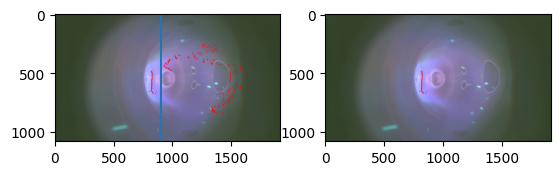

In [47]:
from methods_script.OFIT.OFIT import process_image, field_edge_detection

fig, (ax1,ax2) = plt.subplots(1,2)

#retreive raw image
raw_image = rev_image(1641,244)

#convert image to grayscale and find edge
target_image = process_image(raw_image,apply_hsv_mask=False)
(x_high, y_high), (x_low, y_low) = field_edge_detection(target_image)

#plot overlay image
x_com, y_com = np.append(x_high, x_low), np.append(y_high,y_low)
overlayed_image = raw_image.copy()
for x,y in zip(x_com, y_com):
    overlayed_image[y-3:y+3,x-3:x+3] = [255,0,0]

ax1.imshow(overlayed_image)
ax1.axvline(900)

#extract edge within high field side

edge_indices = np.where(x_com < 900)
x_edge, y_edge = x_com[edge_indices], y_com[edge_indices]

#overlay detected edge into image
overlayed_image = raw_image.copy()
for x,y in zip(x_edge, y_edge):
    overlayed_image[y-3:y+3,x-3:x+3] = [255,0,0]

ax2.imshow(overlayed_image)

#add x_edge and y_edge into port_set
offset = np.arange(-7, 8, 1)  # -3, -2, ..., 3
for x, y in zip(x_edge, y_edge):
    for dx in offset:
        for dy in offset:
            port_set.add((x + dx, y + dy))

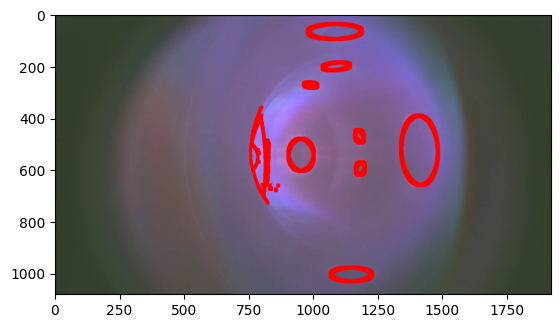

In [48]:
# overlay detected points to image
overlay = rev_image(961,197).copy()
for i,j in port_set:
    overlay[j,i] = [255,0,0]

plt.imshow(overlay)

## Tokamak center

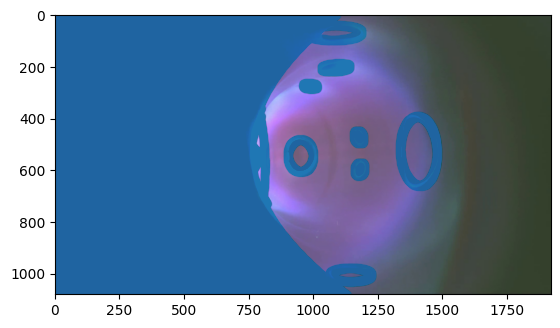

In [49]:
y_center = np.linspace(0,height,height+1)
x_center = side_parabola(y_center,*center_params)

for y in range(height):
    max_x = side_parabola(y,*center_params)
    ex_set.update((x,y) for x in range(int(max_x)))

ex_arr = np.array(list(ex_set))
plt.plot(ex_arr[:,0], ex_arr[:,1],".",alpha = 0.05)
plt.xlim(0,width)
plt.ylim(0,height)
plt.imshow(shot_961_187)
plt.gca().invert_yaxis()
plt.show()

# save result with pickle

In [50]:
#save in pickel file as set of (column, row)

# with open("TT1_structure_pixel.pkl","wb") as file:
#     pickle.dump(ex_set,file)

with open("TT1_port_pixel.pkl", "wb") as port:
    pickle.dump(port_set,port)

# Use edge detection to determine more machine edge

As of October 2025, find_edge detects edge of machine in the high field as plasma edge. 
Use this edge detection to remove the detected pixels

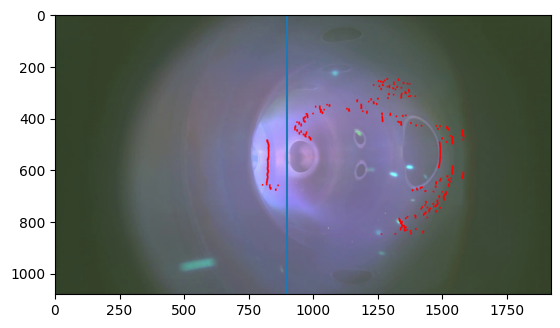

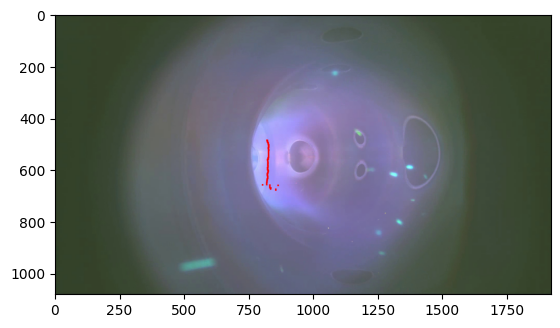